## Homework: Linear regression on car fuel efficiency

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

Let's start by downloading the dataset we will use during this notebook. We use 'wget'

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

!wget $data

--2026-03-05 17:47:35--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.007s  

2026-03-05 17:47:35 (123 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [5]:
df = pd.read_csv(data)

df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


All column names have a similar format using lowercase and '_' instead of whitespaces. So no change is needed in that regard.

Let's have a look at data types and cardinality in the categorical variables.

In [8]:
dtypes = list([df.dtypes])
dtypes

[engine_displacement      int64
 num_cylinders          float64
 horsepower             float64
 vehicle_weight         float64
 acceleration           float64
 model_year               int64
 origin                     str
 fuel_type                  str
 drivetrain                 str
 num_doors              float64
 fuel_efficiency_mpg    float64
 dtype: object]

#### We will only work using the numerical variables contained in the dataset to predict `fuel_efficiency_mpg`:
* `engine_displacement`
* `horsepower`
* `vehicle_weight`
* `model_year`

So we will drop all other variables from the dataset.


In [17]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


#### Exploratory Data Analysis

Let's have a look at `fuel_efficiency_mpg` distribution.


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

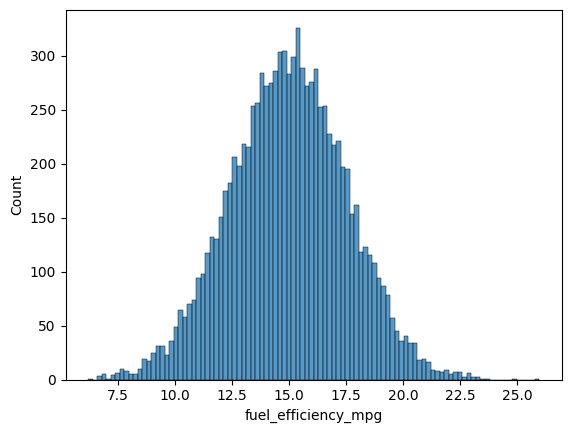

In [19]:
sns.histplot(df.fuel_efficiency_mpg, bins = 100)

Clearly this corresponds to a normal distribution, so the model will do well to predict values and no transformation is needed.

Let's look for **missing values** in the dataset

In [21]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [35]:
missing_percentage = (df.isnull().sum().max()/df.shape[0]) * 100
print (str(round(missing_percentage, 2))+'% of all horsepower rows missing')

7.3% of all horsepower rows missing


So only 7.3% of data is missing and the only column missing data is `horsepower`

#### Question 2: median value for `horsepower`


In [36]:
df.horsepower.describe()

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

#### We will prepare the validation framework using this split:
    ** Training 60% / Validation 20% / Test 20% **

Firstly, let's shuffle the data (we will use seed 42 for reproducibility purposes).

In [38]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

print(n_train, n_val, n_test, n )

5824 1940 1940 9704


In [42]:
idx = np.arange(n)

np.random.seed(42)
np.random.shuffle(idx)
idx

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [44]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


Right now, we have separated the dataset into: **training**, **validation** and **test** datasets and this datasets have been **shuffled** already.


In [47]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

#### Linear regression definition

In [48]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]
    

## Baseline for fuel_efficiency prediction



We will prepare the X matrix for all datasets

In [51]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

X_train = df_train[base].values
X_val = df_val[base].values
X_test = df_test[base].values

#### Filling NA values in horsepower with 0

In [59]:
X_train  = df_train[base].fillna(0).values

w0, w =train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)
y_pred

array([17.33526223, 16.29296317, 17.69885099, ..., 17.54541307,
       18.78287539, 17.86564843], shape=(5824,))

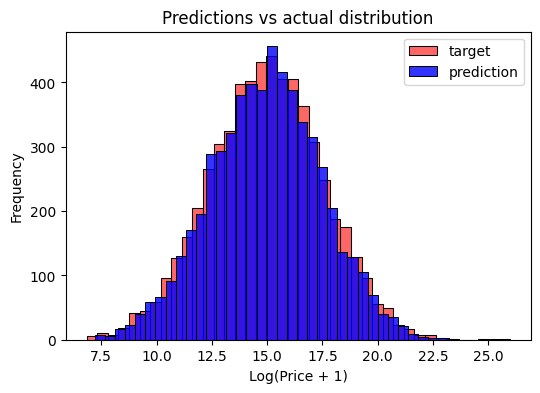

In [60]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='blue', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

The prediction values achieved is **pretty good** (makes sense given how normal the fuel_efficiency distribution actually is)

Let's write the **RMSE** definition

In [61]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [67]:
rmse_fill0 = rmse(y_train, y_pred)

print('RMSE using fill 0: '+str(round(rmse_fill0,2)))

RMSE using fill 0: 0.52


#### Filling NA values in horsepower with median value: 149

In [69]:
X_train = df_train[base].fillna(149).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)
y_pred

array([17.25951753, 16.19051879, 17.69286289, ..., 17.51706796,
       18.77852194, 17.84633066], shape=(5824,))

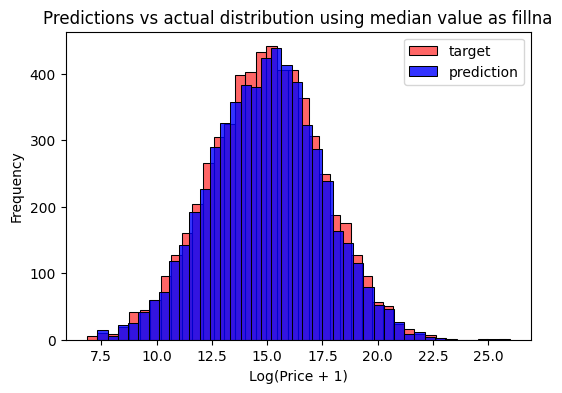

In [71]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='blue', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution using median value as fillna')

plt.show()

In [73]:
rmse_fillmedian = rmse(y_train, y_pred)

print('RMSE using fill 0: '+str(round(rmse_fill0,2)))
print('RMSE using fill median value: '+str(round(rmse_fillmedian,2)))

RMSE using fill 0: 0.52
RMSE using fill median value: 0.46


Both results are really good given the use case, fill0 is just **slightly better**.

 ### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which `r` gives the best RMSE?

### Let's define the regularized linear regression function.

In [74]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [78]:
X_train  = df_train[base].fillna(0).values

for r in [0, 0.01, 0.1, 1, 10]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    print('%5s \t %.2f \t %.2f \t %.2f \t %.2f \t %.2f' % (r, w0, w[0], w[1], w[2], w[3]))

    0 	 28.83 	 0.00 	 0.00 	 -0.01 	 0.00
 0.01 	 24.93 	 0.00 	 0.00 	 -0.01 	 0.00
  0.1 	 11.24 	 0.00 	 0.00 	 -0.01 	 0.01
    1 	 1.73 	 0.00 	 0.00 	 -0.01 	 0.01
   10 	 0.18 	 0.00 	 0.00 	 -0.01 	 0.01


In [81]:
for r in [0, 0.01, 0.1, 1, 10]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_train.dot(w)
    print('RMSE for r=%5s:\t %.2f' % (r, rmse(y_pred,y_train)))

RMSE for r=    0:	 0.52
RMSE for r= 0.01:	 0.52
RMSE for r=  0.1:	 0.52
RMSE for r=    1:	 0.53
RMSE for r=   10:	 0.53


Given the recommendation for choosing the best r value we will use **r=0**


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.001
- 0.006
- 0.060
- 0.600